<h1 align = "center"><code>AutoHolidays</code> Optimized Holiday Planner</h1>

---

`AutoHolidays` is an intelligent Python package that optimizes leave planning by analyzing leave balances, weekends, public holidays, and custom constraints. It calculates strategic combinations to maximize continuous breaks while minimizing leave usage. Designed for individuals and teams, it supports coordinated planning and adapts to diverse organizational policies and regional calendars.

In [1]:
import os
import sys

In [15]:
import calendar
import holidays
import datetime as dt

In [9]:
import numpy as np

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

In [3]:
sys.path.append(os.path.join(".."))

In [4]:
import autoholidays as ah

## Person and Plan Definition

In [6]:
persons = [
  ah.person.PersonConstruct(
    name = "John Doe",
    holidays = [
        dt.date(2026, 5, 1), dt.date(2026, 9, 14), dt.date(2026, 10, 2), dt.date(2026, 10, 20),
        dt.date(2026, 11, 9), dt.date(2026, 11, 10), dt.date(2026, 12, 25), dt.date(2027, 1, 1),
        dt.date(2027, 1, 26), dt.date(2027, 3, 22)
    ],
    creditDays = [
      ah.calendar.CreditDays(name = "GL", days = 9, date = dt.date(2026, 4, 1)),
      ah.calendar.CreditDays(name = "PL", days = 21, date = dt.date(2026, 4, 1))
    ]
  ),

  ah.person.PersonConstruct(
    name = "Jane Doe",
    opening = 11,
    holidays = [
        dt.date(2026, 3, 4), dt.date(2026, 3, 21), dt.date(2026, 3, 31), dt.date(2026, 4, 3), dt.date(2026, 5, 1),
        dt.date(2026, 5, 27), dt.date(2026, 6, 27), dt.date(2026, 8, 15), dt.date(2026, 8, 26), dt.date(2026, 10, 2),
        dt.date(2026, 10, 9), dt.date(2026, 10, 20), dt.date(2026, 11, 8), dt.date(2026, 11, 24),
        dt.date(2027, 1, 26), dt.date(2027, 3, 22)
    ],
    weekoff = [ ah.calendar.ENUMDays.SUNDAY ],
    creditDays = [
      ah.calendar.CreditDays(name = "EL", days = 9, date = dt.date(2026, 7, 1))
    ]
  )
]

cycle = ah.calendar.PlanningCycle(start = dt.date(2026, 4, 1), final = dt.date(2027, 3, 31))
planner = ah.AutoHoliday(cycle = cycle, persons = persons)

In [8]:
plans = planner.plan()
for person in persons:
    print(f"Required Leave for {person.name:<10}: {planner.calculateLeaveDays(person, plans):,}")

Required Leave for John Doe  : 57
Required Leave for Jane Doe  : 78


In [10]:
PALETTE = [
    "#5DCAA5",  # teal
    "#7F77DD",  # purple
    "#EF9F27",  # amber
    "#D85A30",  # coral
    "#378ADD",  # blue
    "#D4537E",  # pink
    "#639922",  # green
    "#E24B4A",  # red
]

In [19]:
def visualize_calendar(
    date_lists: list[list[dt.date]],
    cycle_start: dt.date,
    cycle_end: dt.date,
    title: str = "Calendar",
    colors: list[str] | None = None,
    figsize: tuple[float, float] | None = None,
) -> plt.Figure:
    if colors is None:
        colors = PALETTE
 
    # Build a {date: range_index} lookup
    date_color: dict[dt.date, int] = {}
    for idx, date_range in enumerate(date_lists):
        for d in date_range:
            if cycle_start <= d <= cycle_end:
                date_color[d] = idx
 
    # Collect all (year, month) pairs in the cycle
    months: list[tuple[int, int]] = []
    cur = dt.date(cycle_start.year, cycle_start.month, 1)
    last = dt.date(cycle_end.year, cycle_end.month, 1)
    while cur <= last:
        months.append((cur.year, cur.month))
        # advance one month
        if cur.month == 12:
            cur = dt.date(cur.year + 1, 1, 1)
        else:
            cur = dt.date(cur.year, cur.month + 1, 1)
 
    # Layout: up to 4 months per row
    cols = min(4, len(months))
    rows = (len(months) + cols - 1) // cols
 
    cell_w, cell_h = 2.4, 2.0          # inches per month cell
    legend_h = 0.6 + 0.3 * len(date_lists)
    title_h = 0.5
 
    if figsize is None:
        figsize = (cols * cell_w + 0.4, rows * cell_h + legend_h + title_h)
 
    fig = plt.figure(figsize=figsize, facecolor="white")
 
    # --- Title ---
    fig.text(
        0.5, 1 - title_h / figsize[1] * 0.5,
        title,
        ha="center", va="center",
        fontsize=14, fontweight="bold", color="#222",
    )
 
    DAYS = ["Mo", "Tu", "We", "Th", "Fr", "Sa", "Su"]
    day_lw = 0.5    # line width for cell borders
    day_alpha = 0.06
 
    for mi, (year, month) in enumerate(months):
        row = mi // cols
        col = mi % cols
 
        # Axes position (left, bottom, width, height) in figure fraction
        ax_l = (col * cell_w + 0.2) / figsize[0]
        ax_b = 1 - (title_h + (row + 1) * cell_h) / figsize[1] + legend_h / figsize[1]
        ax_w = (cell_w - 0.15) / figsize[0]
        ax_h = (cell_h - 0.15) / figsize[1]
 
        ax = fig.add_axes([ax_l, ax_b, ax_w, ax_h])
        ax.set_xlim(0, 7)
        ax.set_ylim(0, 7)           # 1 header row + up to 6 weeks
        ax.axis("off")
 
        # Month header
        ax.text(
            3.5, 6.65,
            calendar.month_name[month] + f" {year}",
            ha="center", va="center",
            fontsize=9, fontweight="bold", color="#333",
        )
 
        # Day-of-week headers
        for di, day_name in enumerate(DAYS):
            ax.text(
                di + 0.5, 6.15,
                day_name,
                ha="center", va="center",
                fontsize=7, color="#888",
            )
 
        # Fill day cells
        first_weekday, n_days = calendar.monthrange(year, month)  # 0=Mon
        # calendar module: 0=Mon, so shift to match DAYS starting at Mon
        start_col = first_weekday  # 0-6
 
        week = 0
        for day in range(1, n_days + 1):
            slot = start_col + day - 1
            wk = slot // 7
            dc = slot % 7
 
            x = dc
            y = 5 - wk   # y=5 is the top data row
 
            d = dt.date(year, month, day)
            in_cycle = cycle_start <= d <= cycle_end
 
            # Background cell
            rect_color = "#f5f5f5" if in_cycle else "#fafafa"
            rect = FancyBboxPatch(
                (x + 0.05, y + 0.08), 0.9, 0.8,
                boxstyle="round,pad=0.05",
                linewidth=day_lw, edgecolor="#ddd",
                facecolor=rect_color,
            )
            ax.add_patch(rect)
 
            # Colored overlay if the date is in one of the ranges
            if d in date_color:
                idx = date_color[d]
                c = colors[idx % len(colors)]
                crect = FancyBboxPatch(
                    (x + 0.05, y + 0.08), 0.9, 0.8,
                    boxstyle="round,pad=0.05",
                    linewidth=1.2, edgecolor=c,
                    facecolor=c + "cc",   # ~80% opacity
                )
                ax.add_patch(crect)
                txt_color = "white"
            else:
                txt_color = "#333" if in_cycle else "#bbb"
 
            ax.text(
                x + 0.5, y + 0.5,
                str(day),
                ha="center", va="center",
                fontsize=7.5,
                color=txt_color,
                fontweight="bold" if d in date_color else "normal",
            )
 
    return fig

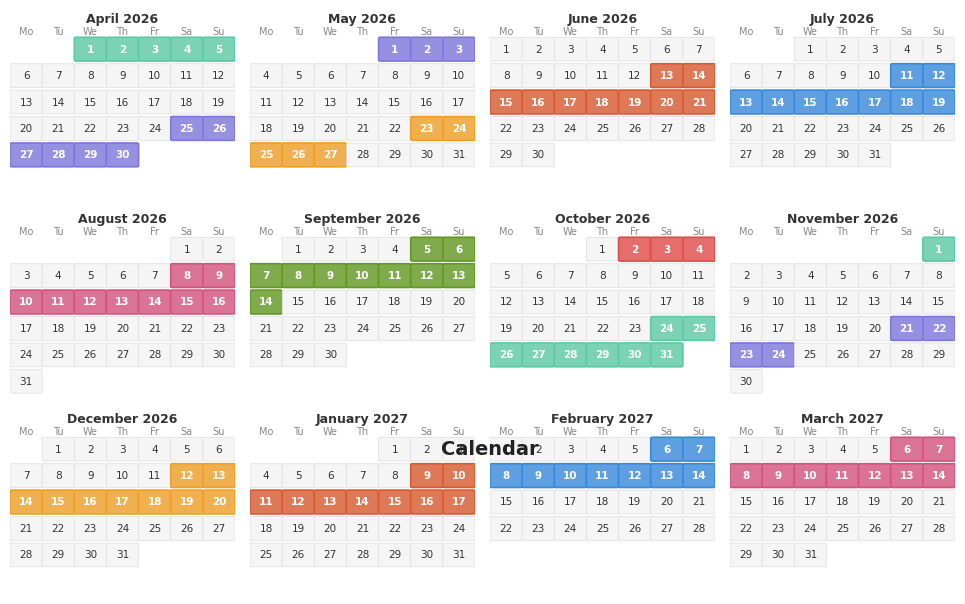

In [20]:
_ = visualize_calendar(plans, cycle.start, cycle.final)